In [4]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.offline import iplot
import plotly.express as px

plt.rcParams['figure.figsize'] = [20, 10]
import pandas as pd
%matplotlib inline

In [5]:
#Read the cleaned data for all stations

cleaned_df = []

for i in range (1, 7) :

    #Read in the cleaned data
    df_1c = pd.read_csv('../datasets/TX-Data/soil_station_cleanedup/SM_' + str(i) + '_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
    #Pandas remove spaces in the column names
    df_1c.columns = df_1c.columns.str.replace(' ','')
    df_1c['SWC_5'] = df_1c['SWC_5'].astype(float)
    df_1c['SWC_10'] = df_1c['SWC_10'].astype(float)
    df_1c['SWC_20'] = df_1c['SWC_20'].astype(float)
    df_1c['SWC_50'] = df_1c['SWC_50'].astype(float)

    df_1c['T_5'] = df_1c['T_5'].astype(float)
    df_1c['T_10'] = df_1c['T_10'].astype(float)
    df_1c['T_20'] = df_1c['T_20'].astype(float)
    df_1c['T_50'] = df_1c['T_50'].astype(float)
    
    #Add cleaned df to a list
    cleaned_df.append(df_1c)

print('station 1 cleaned data:')
print(cleaned_df[0])

station 1 cleaned data:
                      Ppt  SWC_5  SWC_10  SWC_20  SWC_50    T_5   T_10   T_20  \
Date                                                                            
2015-01-01 00:00:00  0.00  0.139   0.178   0.148   0.152   2.81   4.40   5.77   
2015-01-01 01:00:00  0.00  0.139   0.178   0.148   0.152   2.86   4.38   5.71   
2015-01-01 02:00:00  0.00  0.139   0.178   0.148   0.152   2.89   4.35   5.66   
2015-01-01 03:00:00  0.00  0.139   0.178   0.148   0.152   2.90   4.33   5.62   
2015-01-01 04:00:00  0.00  0.139   0.178   0.148   0.152   2.96   4.32   5.59   
2015-01-01 05:00:00  0.00  0.139   0.178   0.148   0.152   2.89   4.30   5.54   
2015-01-01 06:00:00  0.00  0.139   0.178   0.148   0.152   2.73   4.25   5.51   
2015-01-01 07:00:00  0.00  0.139   0.177   0.148   0.152   2.64   4.18   5.46   
2015-01-01 08:00:00  0.00  0.139   0.177   0.148   0.152   2.64   4.11   5.39   
2015-01-01 09:00:00  0.00  0.139   0.177   0.148   0.152   2.67   4.07   5.34   
2015

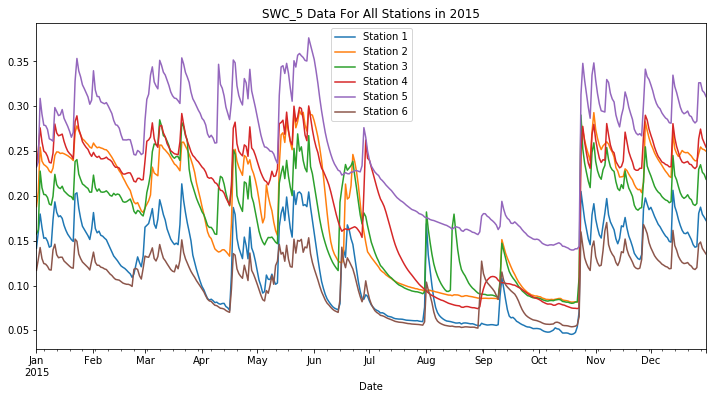

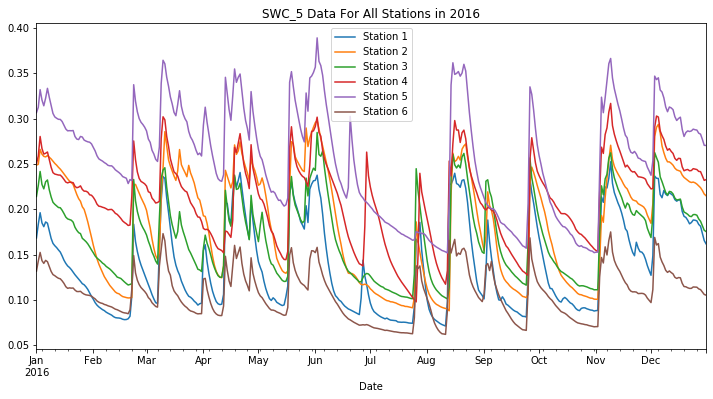

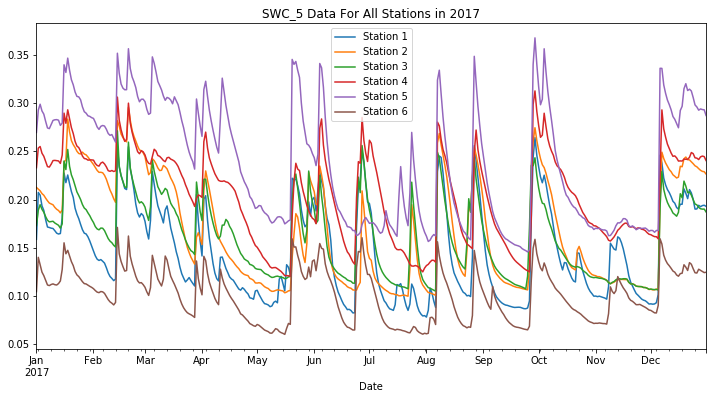

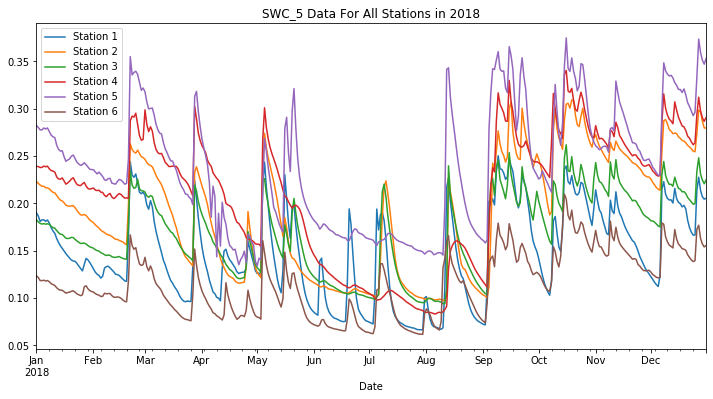

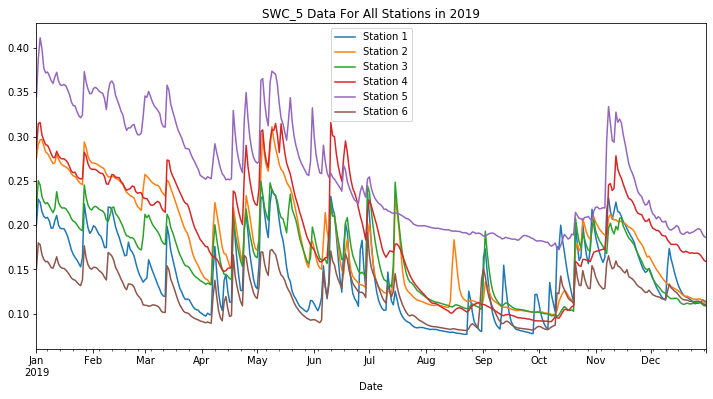

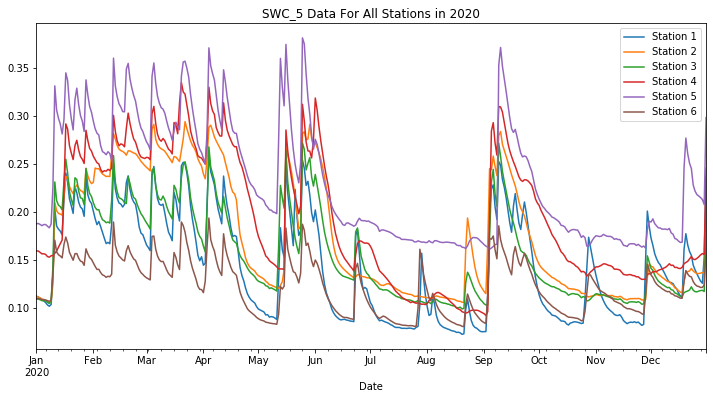

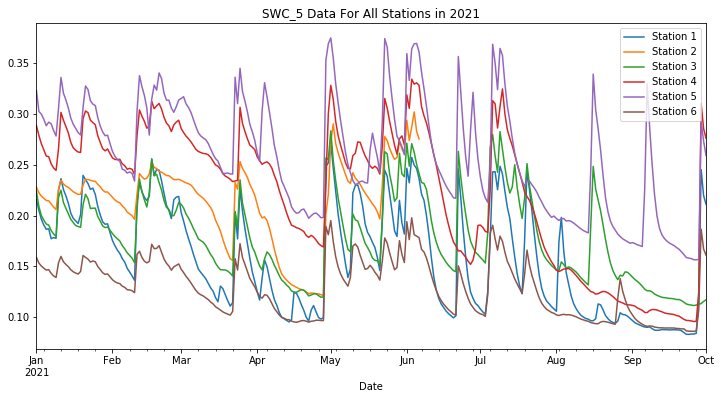

In [6]:
# plot the soil moisture content (SWC_5 only) for the cleaned soil data (comparing all stations in every year)
years = [str(item) for item in range(2015, 2022)]

# Iterate over each year of data
for year in years :
    # Plot station 1 to obtain the axes for this year
    axes = cleaned_df[0][year].resample('D').mean().plot(figsize=(12,6), y=["SWC_5"], label=['Station 1'])
    # Plot each station's SWC_5 data in this year (from Station 2 onward)
    for index in range(1, 6) :
        cleaned_df[index][year].resample('D').mean().plot(figsize=(12,6), y=["SWC_5"], ax=axes, label=['Station ' + str(index + 1)])
    plt.legend()
    plt.title("SWC_5 Data For All Stations in " + year)
    plt.show()

In [7]:
# create a plotly figure
fig = go.Figure()
# plot all 6 station's SWC_5 data
for index in range(0, 6) :
    fig.add_scatter(x = cleaned_df[index].index, y = cleaned_df[index]['SWC_5'], mode = 'lines', name = 'Station ' + str(index + 1))
# update the title and axes of the figure
fig.update_layout(title="SWC_5 Data For All Stations", xaxis_title = "Date", legend_title = "Stations")
# open the html file and add on this new generated plot
with open('SWC_5_comparison_graphs.html', 'a') as file :
    file.write(fig.to_html(full_html = False, include_plotlyjs = 'cdn'))

print("All graphs uploaded to: SWC_5_comparison_graphs.html")

All graphs uploaded to: SWC_5_comparison_graphs.html


In [8]:
# store GPS positions of all stations in a list
gps_list = ['Latitude 30.3989 Longitude -98.6105', 'Latitude 30.4193 Longitude -98.8046', 'Latitude 30.4421 Longitude -98.8427',
           'Latitude 30.4600 Longitude -98.9407', 'Latitude 30.2454 Longitude -98.7059', 'Latitude 30.2758 Longitude -98.7242']

# calculate average percent change in SWC_5 between Station X and other stations
station = 0
for df in cleaned_df :
    station += 1
    s_5 = df['SWC_5']
    print('Average percent change between Station ' + str(station) + ' and other Stations:')
    print('GPS position for Station ' + str(station) + ': ' + gps_list[station - 1] + '\n')
    station_c = 0
    # compare with other stations
    for df_compare in cleaned_df :
        station_c += 1
        sc_5 = df_compare['SWC_5']
        # don't compare the same station with itself
        if s_5.equals(sc_5) :
            continue
        # calculate percent change with original as s_5 and new as sc_5
        percent_change = ((sc_5 - s_5) / s_5) * 100
        # get average percent change value
        avg_pc = percent_change.mean()
        print('Station ' + str(station_c) + ': ' + str(avg_pc))
    print()

Average percent change between Station 1 and other Stations:
GPS position for Station 1: Latitude 30.3989 Longitude -98.6105

Station 2: 32.20386296301914
Station 3: 23.837753836521216
Station 4: 49.549054737012405
Station 5: 86.36284828142546
Station 6: -16.08288485349127

Average percent change between Station 2 and other Stations:
GPS position for Station 2: Latitude 30.4193 Longitude -98.8046

Station 1: -20.46220664359705
Station 3: -5.5364643134746645
Station 4: 15.37061084325157
Station 5: 42.17308276820949
Station 6: -34.784724899789836

Average percent change between Station 3 and other Stations:
GPS position for Station 3: Latitude 30.4421 Longitude -98.8427

Station 1: -15.49369308984884
Station 2: 8.193516397671496
Station 4: 22.24649202213567
Station 5: 50.724677080236056
Station 6: -30.650448540536964

Average percent change between Station 4 and other Stations:
GPS position for Station 4: Latitude 30.4600 Longitude -98.9407

Station 1: -28.950431230698594
Station 2: -10.

## GPS Locations of all 6 Stations

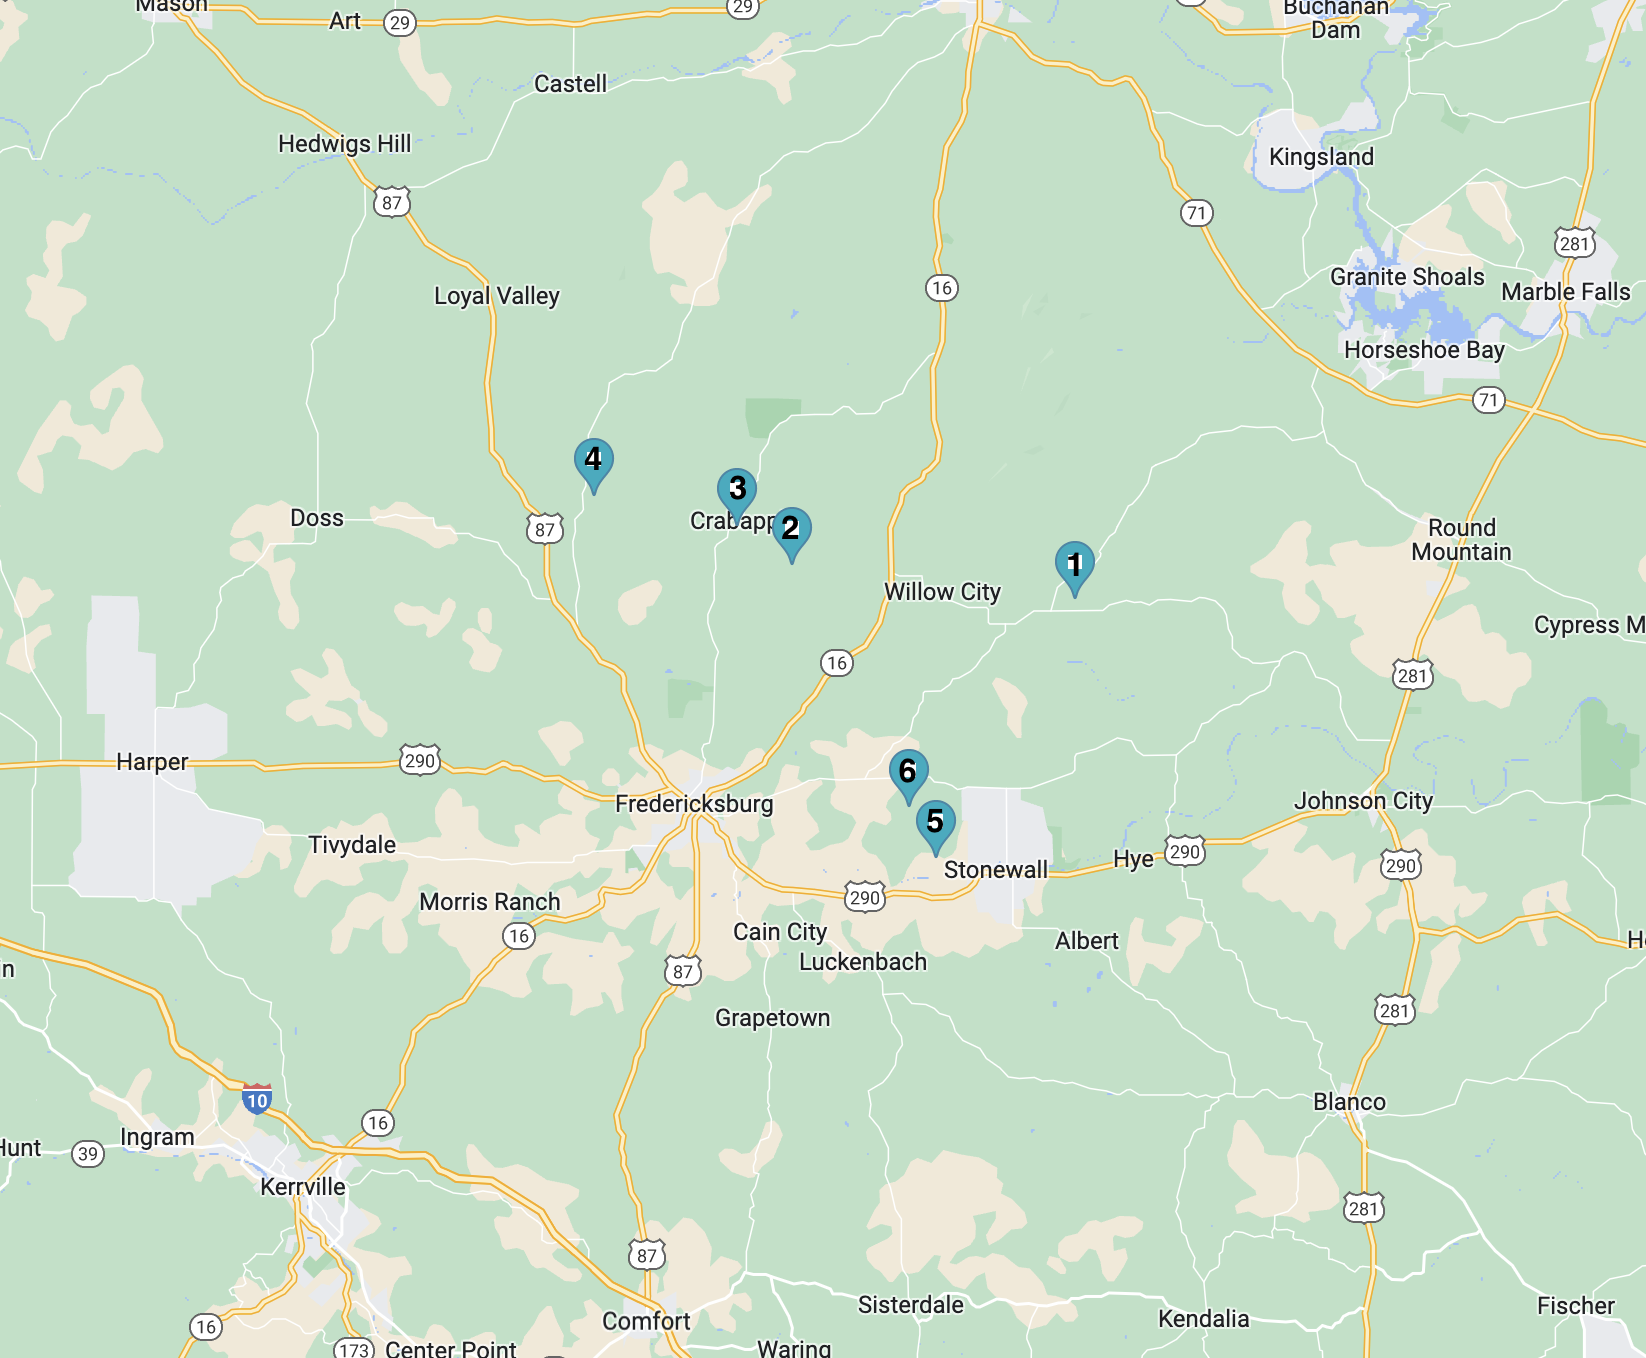

## Analysis
Based on the graphs and the average percent change numbers for each station, we can observe that Station 1 had similar rainfall levels to every station besides Station 5, which is the furthest in distance from Station 1. Station 6 was very correlated in moisture content with Station 1, which makes sense as they are geographically neighboring stations. For Station 2, it had strong similarities with Station 3 (its next door neighbor), and generally similar moisture contents with other stations (with the exceptions of Station 5 and 6 which are the farthest from it). For Station 3, it correlated well with Station 2 and generally well with the other station (except for Station 5 and 6 once again which are far from this Station). Station 4 mirrors moisture contents with Stations 2 and 3 well (its closest neighbors) and does okay with Stations 1 and 5. Station 5's moisture content correlates well with Stations 4 and 2, and correlates less well with Station 3. Station 5 seems to differ more greatly with Stations 1 and 6. Station 6 tracks really similar to Station 1 and is similar with Stations 2 and 3, which makes sense based on the geography as Station 6 is somewhat closer to Station 1 than Stations 2 and 3. However, Station 6 differs the most with Station 5 when it comes to soil moisture content. The general order of most soil moisture content to least is as follows: Stations 5, 4, 2, 3, 1, and 6. The only inconsistency I'm noticing is Stations 5 and 6, which appear to be geographically next to each other but differ the greatest in soil moisture content values. Could this be an issue with the sensor equipment, station infrastructure, or due to the land/soil features of these stations?

# Extra Context: A Comparison of SWC_50 Values Across All Stations

In [9]:
# create a plotly figure
fig = go.Figure()
# plot all 6 station's SWC_50 data
for index in range(0, 6) :
    fig.add_scatter(x = cleaned_df[index].index, y = cleaned_df[index]['SWC_50'], mode = 'lines', name = 'Station ' + str(index + 1))
# update the title and axes of the figure
fig.update_layout(title="SWC_50 Data For All Stations", xaxis_title = "Date", legend_title = "Stations")
# open the html file and add on this new generated plot
with open('SWC_50_comparison_graphs.html', 'a') as file :
    file.write(fig.to_html(full_html = False, include_plotlyjs = 'cdn'))

print("All graphs uploaded to: SWC_50_comparison_graphs.html")

All graphs uploaded to: SWC_50_comparison_graphs.html


# Specific Case Studies

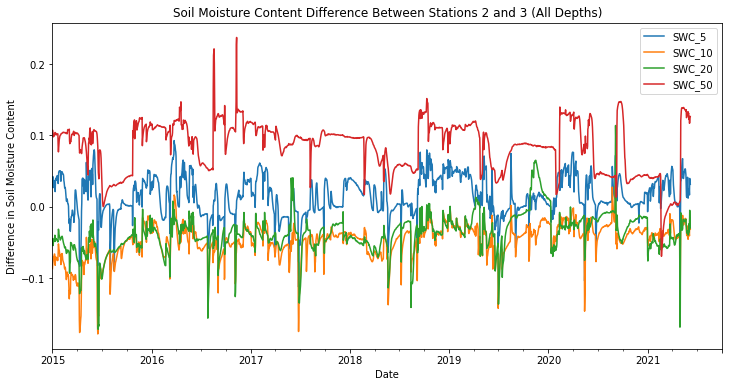

In [10]:
# isolate Station 2 and 3 data
s2_df = cleaned_df[1]
s3_df = cleaned_df[2]

# subtract one df from the other
sub_df = s2_df - s3_df

# plot differences in SWC values
sub_df.resample('D').mean().plot(figsize=(12,6), y=["SWC_5", "SWC_10", "SWC_20", "SWC_50"])
plt.legend()
plt.title("Soil Moisture Content Difference Between Stations 2 and 3 (All Depths)")
plt.ylabel("Difference in Soil Moisture Content")
plt.show()

# Analysis

If the two stations are close to each other (which they are), we can expect that the soil moisture content difference to be consistenly some value (a straight line). Looking at the above graph holistically, we see that this is generally the case, as for all soil depths, the difference in soil moisture hover around a central value (although the lines may appear jagged due to the variances in hourly soil moisture content). Furthermore, we notice that different depths retain soil moisture content at different lengths; Station 2 generally has higher soil moisture contents than Station 3 at 5 cm and 50 cm, while Station 3 generally has higher soil moisture contents at 10 cm and 20 cm depths.

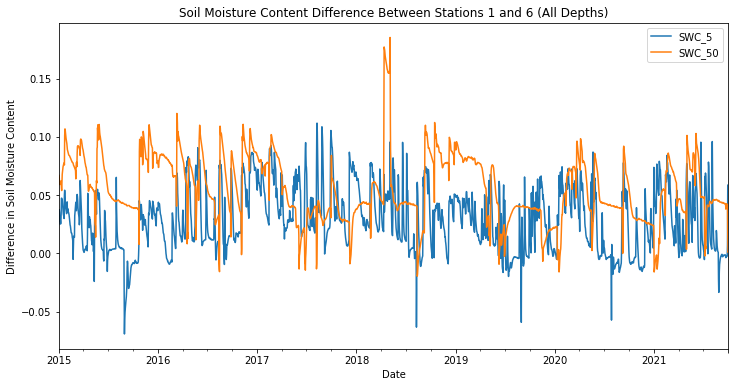

In [11]:
# isolate Station 1 and 6 data
s1_df = cleaned_df[0]
s6_df = cleaned_df[5]

# subtract one df from the other
sub_df = s1_df - s6_df

# plot differences in SWC values
sub_df.resample('D').mean().plot(figsize=(12,6), y=["SWC_5", "SWC_50"])
plt.legend()
plt.title("Soil Moisture Content Difference Between Stations 1 and 6 (All Depths)")
plt.ylabel("Difference in Soil Moisture Content")
plt.show()

# Analysis

I only plotted the shallowest and deepest soil depths for this comparison due to the clutter in the graph if all depths were plotted. Once again, we see expected behavior as the differences in soil moisture content tend to hover around a consistent value throughout the years, with fluctuations due to variability in hourly data. For both depths 5 cm and 50 cm, Station 1 has generally higher soil moisture contents than Station 6.